# Smartphone Addiction Prediction
### CS304N/354N Computational Intelligence Course Project
##Group Members
##Md Asif Hussain (230041021)
##N Sai Sathwik (230041024)
##P Sai Prakul (230041031)
##K Vivek Tej (230041014)
##V Akshay (230041039)
---

## Project Overview
This notebook presents a comparative study of ML/CI techniques for predicting smartphone addiction from behavioral and demographic data.

**Pipeline:**
1. Exploratory Data Analysis (EDA)
2. Preprocessing & Feature Engineering
3. K-Means Clustering (Unsupervised)
4. Supervised Models: Perceptron, Ridge Regression, SVM (multiple kernels), Decision Tree, Ensemble Methods
5. Evaluation & Comparison

0. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Models
from sklearn.linear_model import Perceptron, Ridge, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


---
## 1. Load & Inspect Data

In [ ]:
# ── CHANGE THIS to your actual CSV filename ──
df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Shape: (7500, 16)

Columns: ['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [ ]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


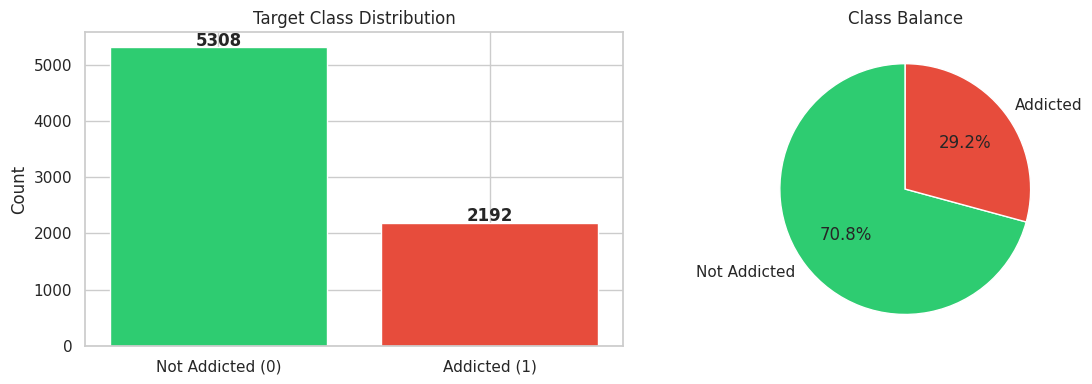

Class balance ratio: 0.41


In [ ]:
# Target distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

counts = df['addicted_label'].value_counts()
ax[0].bar(['Not Addicted (0)', 'Addicted (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Target Class Distribution')
ax[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

ax[1].pie(counts.values, labels=['Not Addicted', 'Addicted'],
          colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
ax[1].set_title('Class Balance')

plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Class balance ratio: {counts[0]/counts[1]:.2f}')

---
## 2. Exploratory Data Analysis (EDA)

In [ ]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from numeric list for plotting
feature_numeric = [c for c in numeric_cols if c != 'addicted_label']

print(f'Numeric features: {feature_numeric}')
print(f'Categorical features: {categorical_cols}')

Numeric features: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
Categorical features: ['transaction_id', 'user_id', 'gender', 'stress_level', 'academic_work_impact', 'addiction_level']


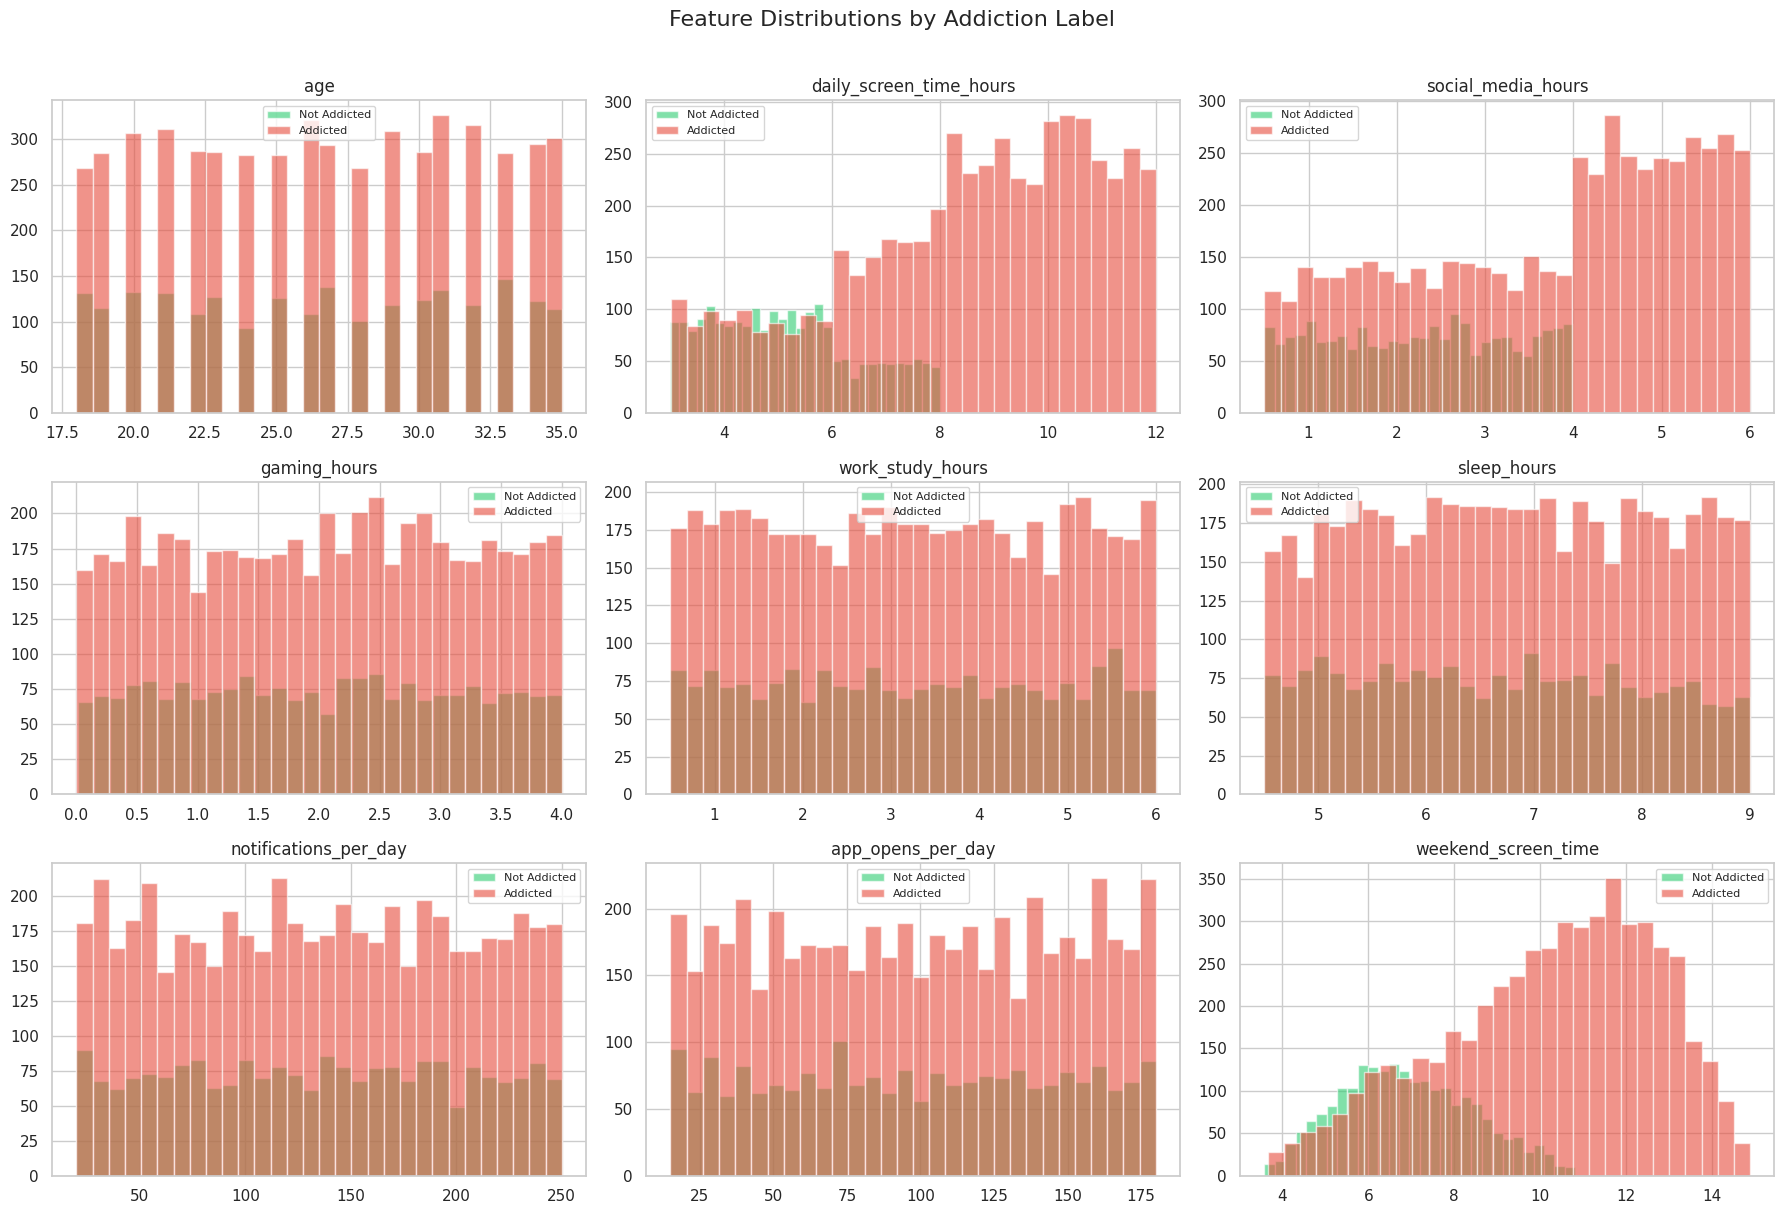

In [ ]:
# Distribution of numeric features
n_cols = 3
n_rows = (len(feature_numeric) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_numeric):
    for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
        axes[i].hist(df[df['addicted_label'] == label][col].dropna(),
                     alpha=0.6, bins=30, color=color,
                     label='Not Addicted' if label == 0 else 'Addicted')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Addiction Label', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

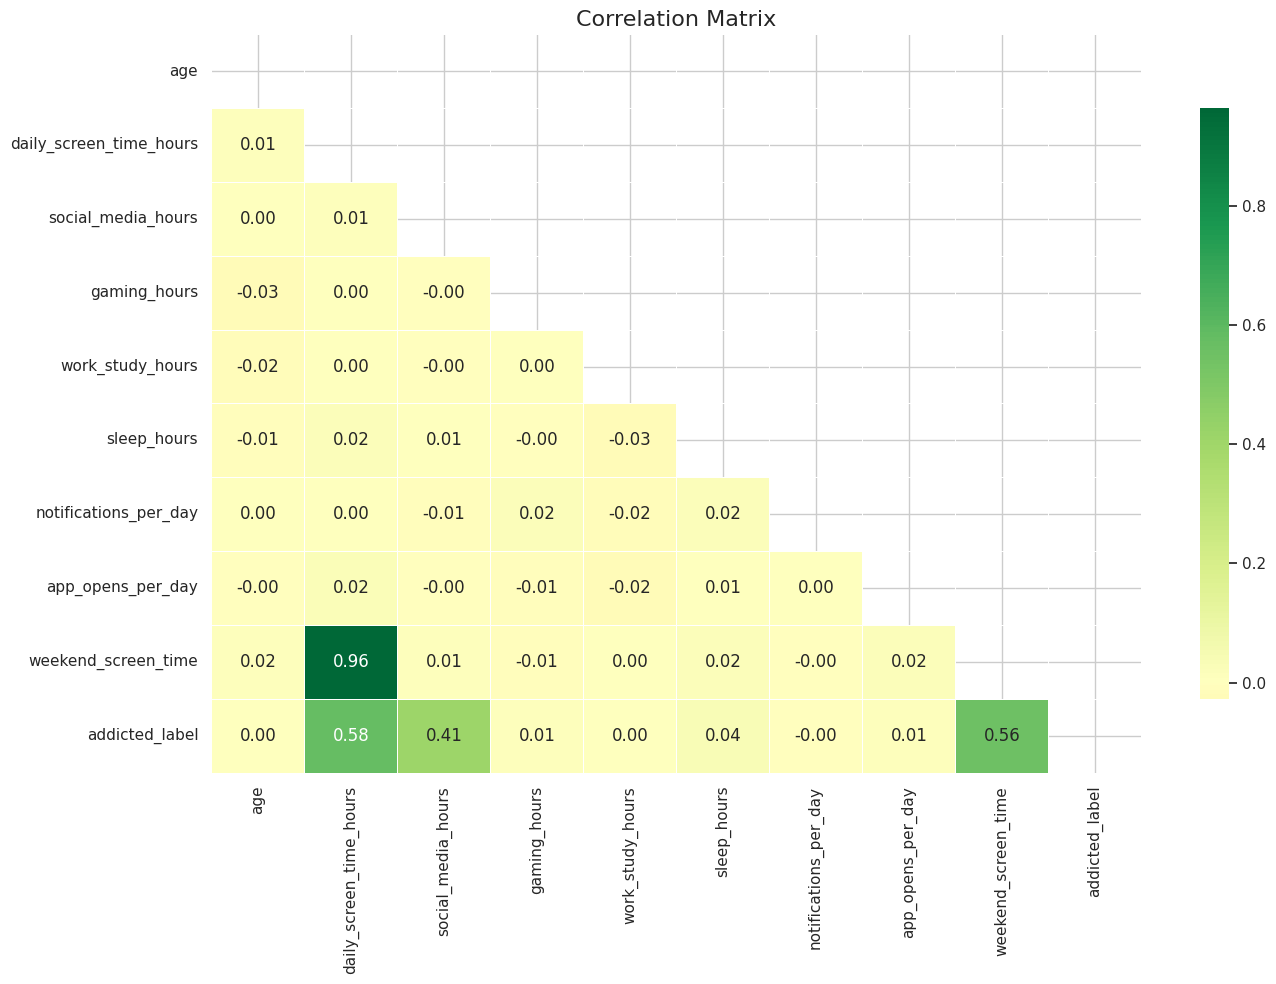

In [ ]:
# Correlation heatmap
corr = df[feature_numeric + ['addicted_label']].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Top correlations with target
target_corr = corr['addicted_label'].drop('addicted_label').abs().sort_values(ascending=False)
print('Feature correlations with addicted_label (absolute value):')
print(target_corr)

Feature correlations with addicted_label (absolute value):
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
social_media_hours         0.414244
sleep_hours                0.035496
app_opens_per_day          0.011041
gaming_hours               0.008485
age                        0.004220
work_study_hours           0.001103
notifications_per_day      0.000660
Name: addicted_label, dtype: float64


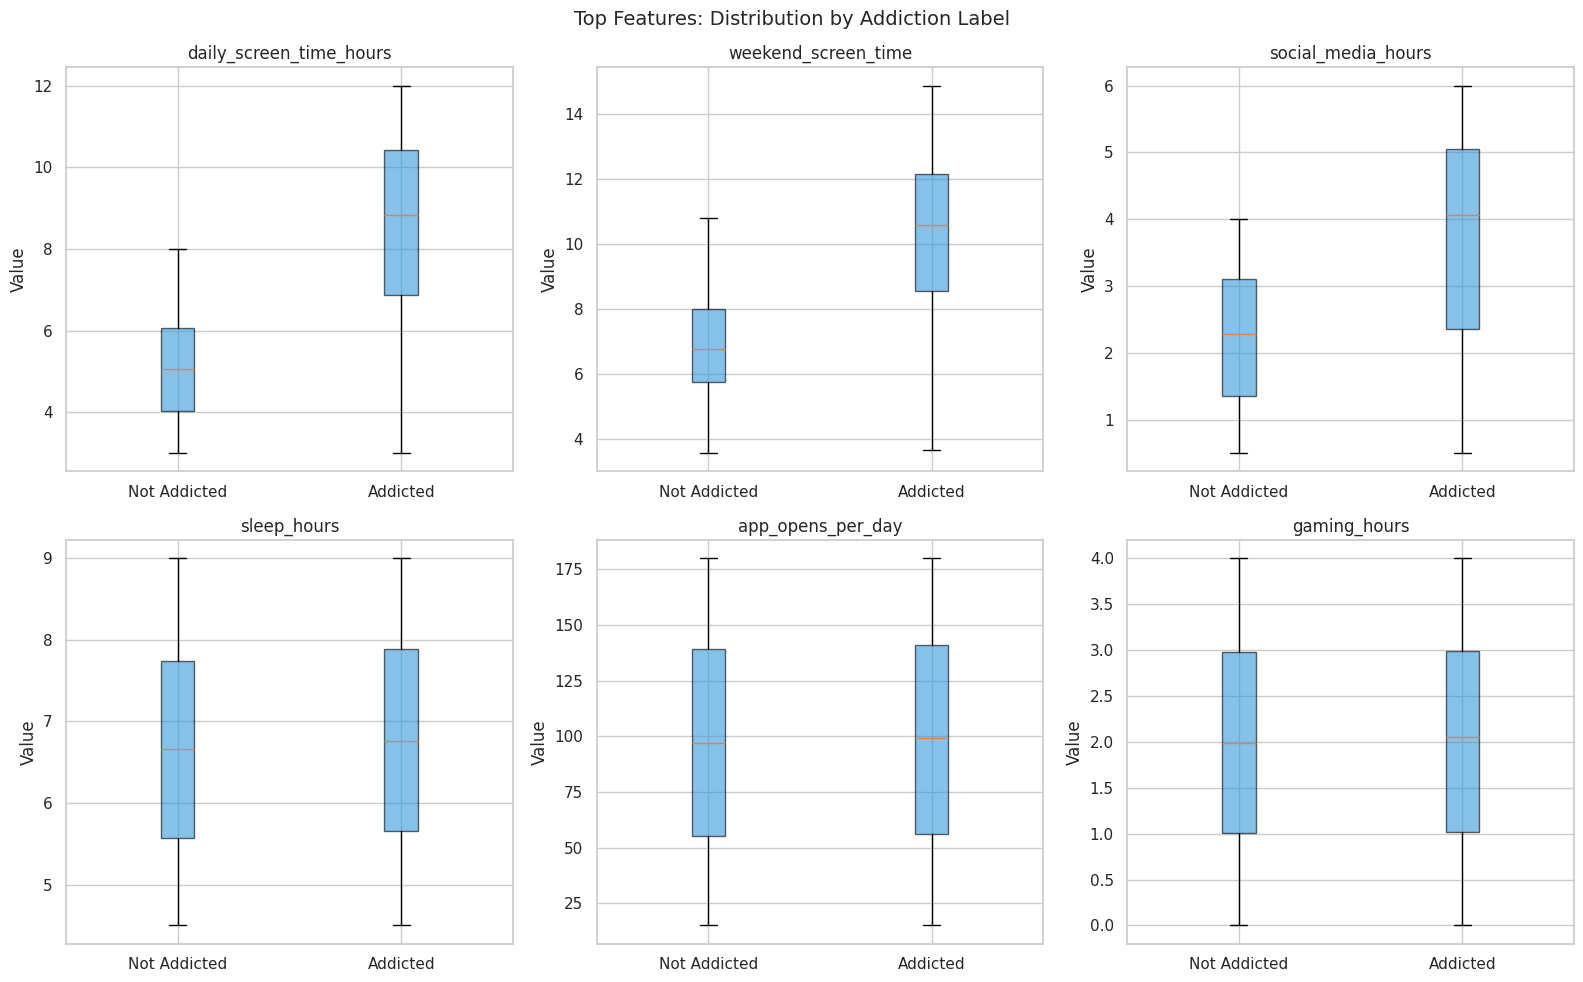

In [ ]:
# Boxplots for top features
top_features = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    data_0 = df[df['addicted_label'] == 0][col].dropna()
    data_1 = df[df['addicted_label'] == 1][col].dropna()
    axes[i].boxplot([data_0, data_1], labels=['Not Addicted', 'Addicted'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Top Features: Distribution by Addiction Label', fontsize=14)
plt.tight_layout()
plt.savefig('fig_boxplots_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Preprocessing

In [ ]:
df_processed = df.copy()

# Identify columns to drop (transaction_id, user_id, addiction_level)
cols_to_drop = ['transaction_id', 'user_id', 'addiction_level']

# Filter categorical columns to encode, excluding those in cols_to_drop
cols_to_encode = [col for col in categorical_cols if col not in cols_to_drop]

# Encode selected categorical columns
le = LabelEncoder()
for col in cols_to_encode:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    print(f'Encoded: {col}')

# Drop the specified columns if they exist
for col in cols_to_drop:
    if col in df_processed.columns:
        df_processed = df_processed.drop(columns=[col])
        print(f"Dropped '{col}' column from df_processed.")

# Separate features and target
X = df_processed.drop(columns=['addicted_label'])
y = df_processed['addicted_label']

print(f'\nFeature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')

Encoded: gender
Encoded: stress_level
Encoded: academic_work_impact
Dropped 'transaction_id' column from df_processed.
Dropped 'user_id' column from df_processed.
Dropped 'addiction_level' column from df_processed.

Feature matrix shape: (7500, 12)
Target shape: (7500,)


In [ ]:
# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train_scaled.shape[0]}')
print(f'Test size:  {X_test_scaled.shape[0]}')
print(f'Train class balance: {pd.Series(y_train).value_counts().to_dict()}')

Train size: 6000
Test size:  1500
Train class balance: {1: 4246, 0: 1754}


---
## 4. K-Means Clustering (Unsupervised Analysis)

**Goal:** Can unsupervised clustering recover the addiction label structure without using any labels?

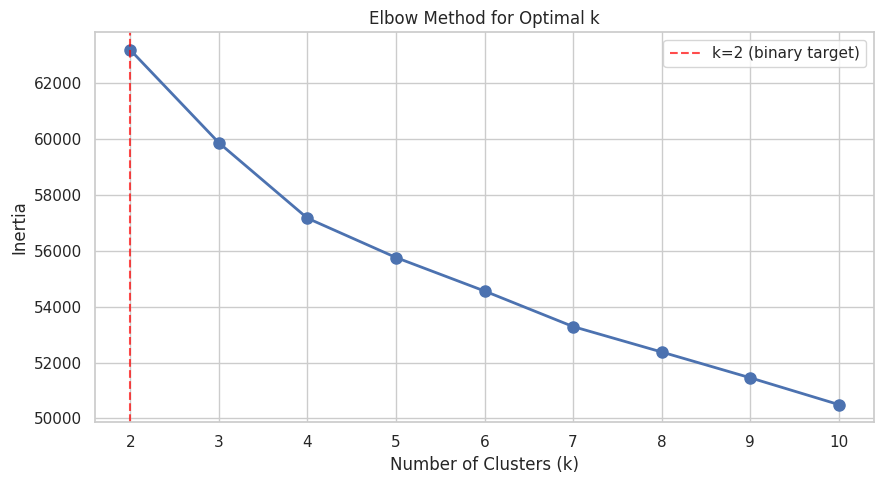

In [ ]:
# Elbow method to find optimal k
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=2, color='red', linestyle='--', alpha=0.7, label='k=2 (binary target)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.legend()
plt.tight_layout()
plt.savefig('fig_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Fit K-Means with k=2
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_scaled)

# Align cluster labels with true labels (Hungarian assignment)
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix as cm

conf = cm(y_train, cluster_labels)
row_ind, col_ind = linear_sum_assignment(-conf)
mapping = dict(zip(col_ind, row_ind))
cluster_labels_aligned = np.array([mapping[c] for c in cluster_labels])

km_acc = accuracy_score(y_train, cluster_labels_aligned)
km_f1 = f1_score(y_train, cluster_labels_aligned)

print(f'K-Means (k=2) — Clustering Accuracy : {km_acc:.4f}')
print(f'K-Means (k=2) — F1 Score            : {km_f1:.4f}')
print('\nNote: Accuracy > 0.5 means clusters have real structure aligned with addiction label.')

K-Means (k=2) — Clustering Accuracy : 0.7625
K-Means (k=2) — F1 Score            : 0.8054

Note: Accuracy > 0.5 means clusters have real structure aligned with addiction label.


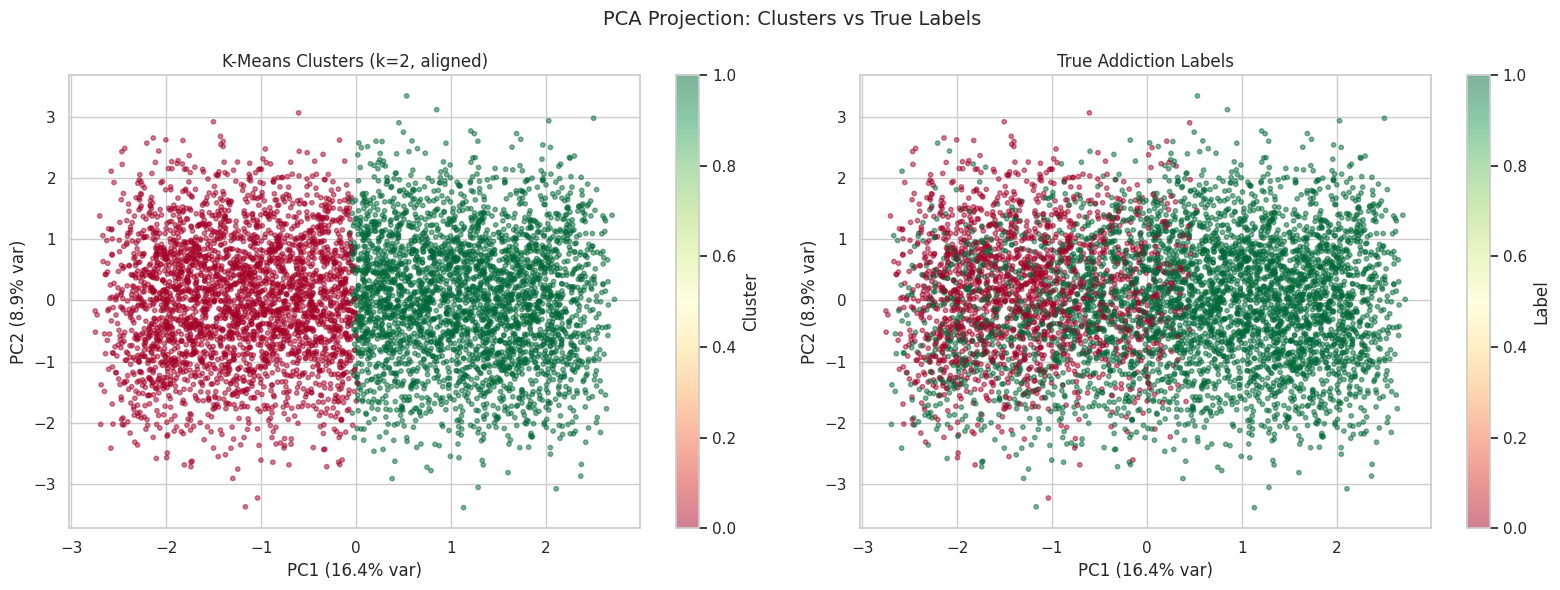

In [ ]:
# Visualize clusters using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means clusters
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=cluster_labels_aligned, cmap='RdYlGn', alpha=0.5, s=10)
axes[0].set_title('K-Means Clusters (k=2, aligned)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# True labels
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=y_train, cmap='RdYlGn', alpha=0.5, s=10)
axes[1].set_title('True Addiction Labels')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter2, ax=axes[1], label='Label')

plt.suptitle('PCA Projection: Clusters vs True Labels', fontsize=14)
plt.tight_layout()
plt.savefig('fig_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Supervised Models

We use a helper function to train, evaluate, and store results consistently.

In [ ]:
results = {}  # stores all model results

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, plot_cm=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None

    results[name] = {
        'Accuracy': acc, 'F1': f1, 'Precision': prec, 'Recall': rec,
        'ROC-AUC': auc if auc else 'N/A'
    }

    print(f'\n──── {name} ────')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    if auc: print(f'  ROC-AUC   : {auc:.4f}')
    print(f'\n{classification_report(y_te, y_pred, target_names=["Not Addicted","Addicted"])}')

    if plot_cm:
        fig, ax = plt.subplots(figsize=(5, 4))
        disp = ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),
                                       display_labels=['Not Addicted', 'Addicted'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'Confusion Matrix — {name}')
        plt.tight_layout()
        plt.savefig(f'fig_cm_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
        plt.show()

    return model

print('Helper function ready.')

Helper function ready.


### 5.1 Perceptron


──── Perceptron ────
  Accuracy  : 0.8387
  F1 Score  : 0.8822
  Precision : 0.9133
  Recall    : 0.8531

              precision    recall  f1-score   support

Not Addicted       0.69      0.80      0.74       438
    Addicted       0.91      0.85      0.88      1062

    accuracy                           0.84      1500
   macro avg       0.80      0.83      0.81      1500
weighted avg       0.85      0.84      0.84      1500



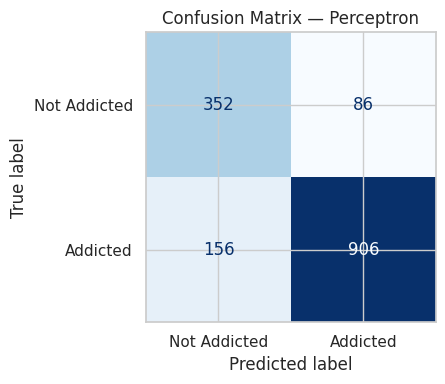

In [ ]:
perceptron = evaluate_model(
    'Perceptron',
    Perceptron(max_iter=1000, random_state=RANDOM_STATE, tol=1e-3),
    X_train_scaled, X_test_scaled, y_train, y_test
)

### 5.2 Ridge Regression (as Classifier)

Ridge Regression minimizes MSE with L2 regularization: **||Xw - y||² + α||w||²**
We threshold at 0.5 to get binary predictions.

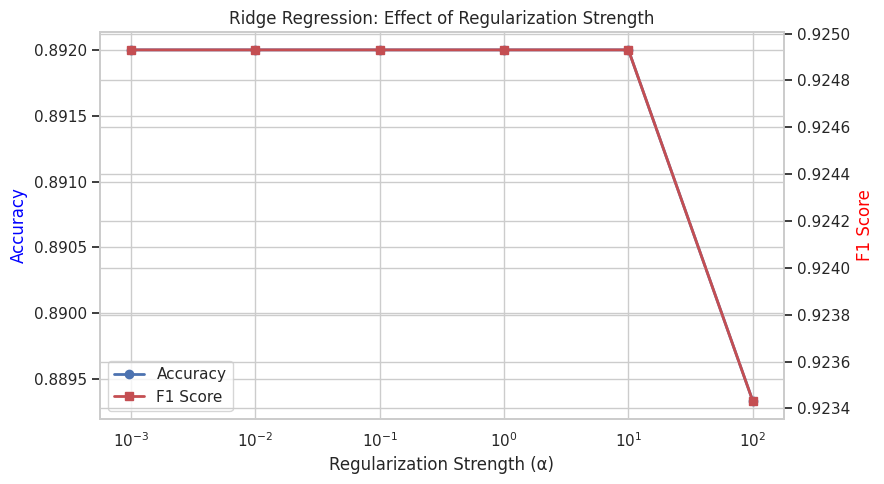

Best alpha: 0.001
  alpha  accuracy       f1
  0.001  0.892000 0.924930
  0.010  0.892000 0.924930
  0.100  0.892000 0.924930
  1.000  0.892000 0.924930
 10.000  0.892000 0.924930
100.000  0.889333 0.923432


In [ ]:
# Ridge: compare different alpha values
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred_r = (ridge.predict(X_test_scaled) >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred_r)
    f1 = f1_score(y_test, y_pred_r)
    ridge_results.append({'alpha': alpha, 'accuracy': acc, 'f1': f1})

ridge_df = pd.DataFrame(ridge_results)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
ax1.semilogx(ridge_df['alpha'], ridge_df['accuracy'], 'b-o', label='Accuracy', linewidth=2)
ax2.semilogx(ridge_df['alpha'], ridge_df['f1'], 'r-s', label='F1 Score', linewidth=2)
ax1.set_xlabel('Regularization Strength (α)')
ax1.set_ylabel('Accuracy', color='blue')
ax2.set_ylabel('F1 Score', color='red')
ax1.set_title('Ridge Regression: Effect of Regularization Strength')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
plt.tight_layout()
plt.savefig('fig_ridge_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

best_alpha = ridge_df.loc[ridge_df['accuracy'].idxmax(), 'alpha']
print(f'Best alpha: {best_alpha}')
print(ridge_df.to_string(index=False))

Ridge (α=0.001) | Acc: 0.8920 | F1: 0.9249


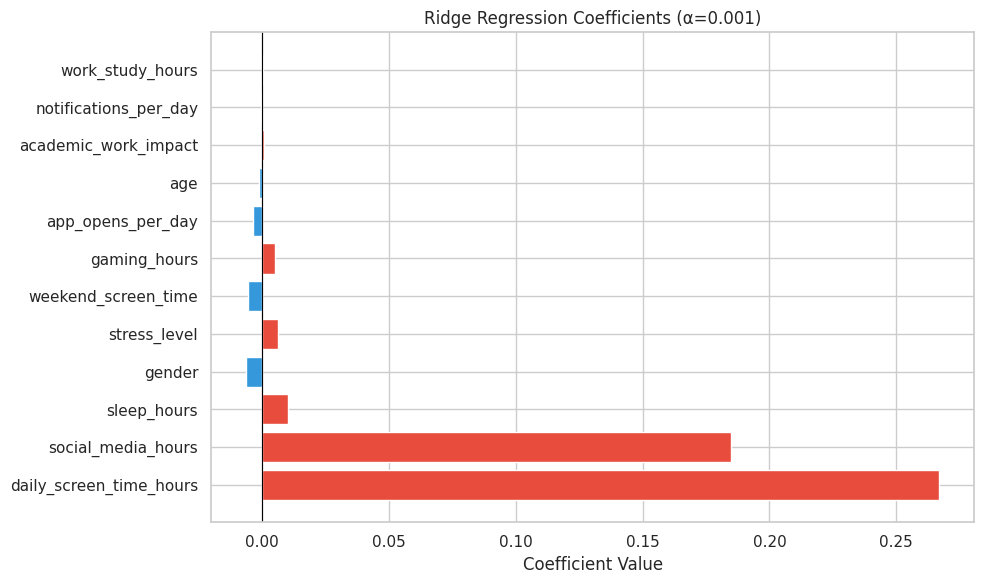

In [ ]:
# Best Ridge model
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(X_train_scaled, y_train)
y_pred_ridge = (best_ridge.predict(X_test_scaled) >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred_ridge)
f1   = f1_score(y_test, y_pred_ridge)
prec = precision_score(y_test, y_pred_ridge)
rec  = recall_score(y_test, y_pred_ridge)

results['Ridge Regression'] = {'Accuracy': acc, 'F1': f1, 'Precision': prec, 'Recall': rec, 'ROC-AUC': 'N/A'}
print(f'Ridge (α={best_alpha}) | Acc: {acc:.4f} | F1: {f1:.4f}')

# Coefficient plot
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': best_ridge.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title(f'Ridge Regression Coefficients (α={best_alpha})')
plt.tight_layout()
plt.savefig('fig_ridge_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 SVM with Multiple Kernels

SVM finds the maximum-margin hyperplane. Kernels implicitly map data to higher-dimensional spaces:
- **Linear**: K(x,z) = xᵀz
- **RBF**: K(x,z) = exp(−γ||x−z||²)
- **Polynomial**: K(x,z) = (γxᵀz + r)^d

Training SVM with linear kernel...

──── SVM (linear) ────
  Accuracy  : 0.8940
  F1 Score  : 0.9270
  Precision : 0.9049
  Recall    : 0.9501
  ROC-AUC   : 0.9541

              precision    recall  f1-score   support

Not Addicted       0.86      0.76      0.81       438
    Addicted       0.90      0.95      0.93      1062

    accuracy                           0.89      1500
   macro avg       0.88      0.85      0.87      1500
weighted avg       0.89      0.89      0.89      1500



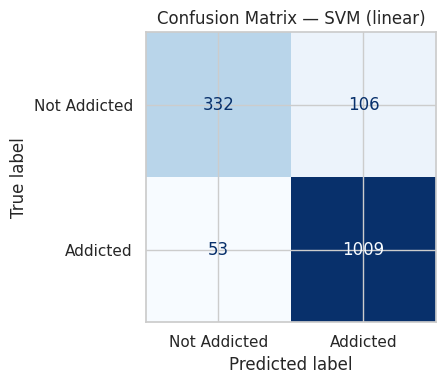

Training SVM with rbf kernel...

──── SVM (rbf) ────
  Accuracy  : 0.9193
  F1 Score  : 0.9434
  Precision : 0.9377
  Recall    : 0.9492
  ROC-AUC   : 0.9753

              precision    recall  f1-score   support

Not Addicted       0.87      0.85      0.86       438
    Addicted       0.94      0.95      0.94      1062

    accuracy                           0.92      1500
   macro avg       0.91      0.90      0.90      1500
weighted avg       0.92      0.92      0.92      1500



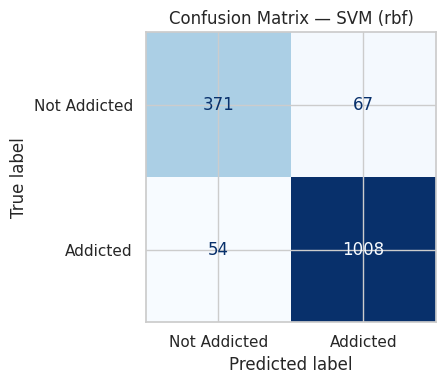

Training SVM with poly kernel...

──── SVM (poly) ────
  Accuracy  : 0.8947
  F1 Score  : 0.9288
  Precision : 0.8910
  Recall    : 0.9699
  ROC-AUC   : 0.9600

              precision    recall  f1-score   support

Not Addicted       0.91      0.71      0.80       438
    Addicted       0.89      0.97      0.93      1062

    accuracy                           0.89      1500
   macro avg       0.90      0.84      0.86      1500
weighted avg       0.90      0.89      0.89      1500



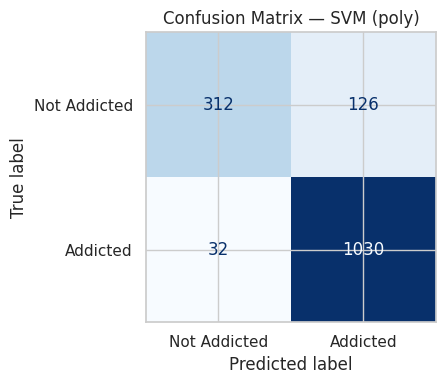

In [ ]:
kernels = ['linear', 'rbf', 'poly']
svm_models = {}

for kernel in kernels:
    print(f'Training SVM with {kernel} kernel...')
    svm = SVC(kernel=kernel, probability=True, random_state=RANDOM_STATE, C=1.0)
    model = evaluate_model(
        f'SVM ({kernel})',
        svm,
        X_train_scaled, X_test_scaled, y_train, y_test,
        plot_cm=True
    )
    svm_models[kernel] = model

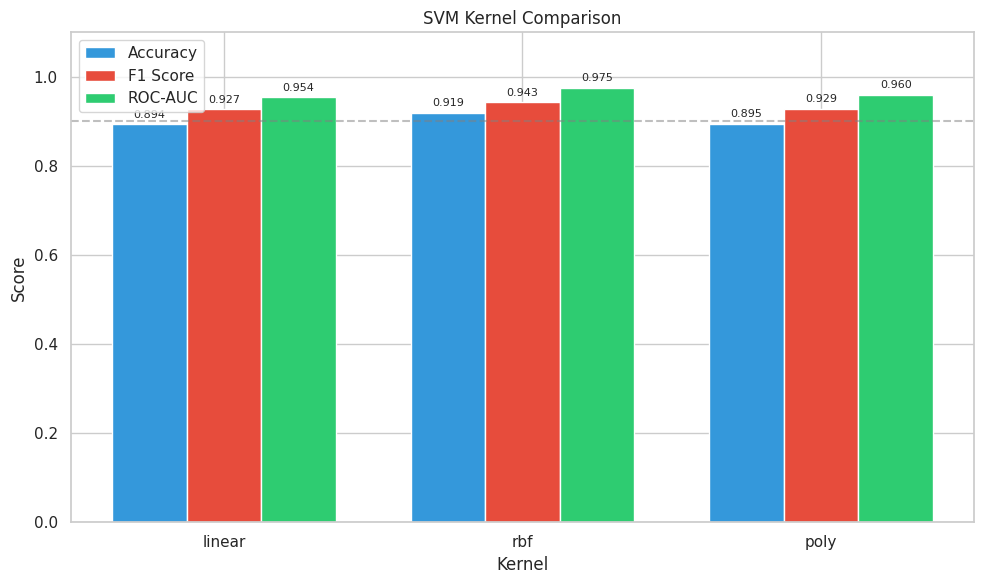

In [ ]:
# SVM Kernel Comparison Plot
svm_results = {k: v for k, v in results.items() if 'SVM' in k}
kernel_names = [k.replace('SVM (', '').replace(')', '') for k in svm_results]
accs = [svm_results[k]['Accuracy'] for k in svm_results]
f1s  = [svm_results[k]['F1'] for k in svm_results]
aucs = [svm_results[k]['ROC-AUC'] if svm_results[k]['ROC-AUC'] != 'N/A' else 0 for k in svm_results]

x = np.arange(len(kernel_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, accs, width, label='Accuracy', color='#3498db')
bars2 = ax.bar(x, f1s, width, label='F1 Score', color='#e74c3c')
bars3 = ax.bar(x + width, aucs, width, label='ROC-AUC', color='#2ecc71')

ax.set_xlabel('Kernel')
ax.set_ylabel('Score')
ax.set_title('SVM Kernel Comparison')
ax.set_xticks(x)
ax.set_xticklabels(kernel_names)
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='0.9 line')

for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig_svm_kernel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Decision Tree


──── Decision Tree ────
  Accuracy  : 0.9307
  F1 Score  : 0.9517
  Precision : 0.9394
  Recall    : 0.9642
  ROC-AUC   : 0.9876

              precision    recall  f1-score   support

Not Addicted       0.91      0.85      0.88       438
    Addicted       0.94      0.96      0.95      1062

    accuracy                           0.93      1500
   macro avg       0.92      0.91      0.91      1500
weighted avg       0.93      0.93      0.93      1500



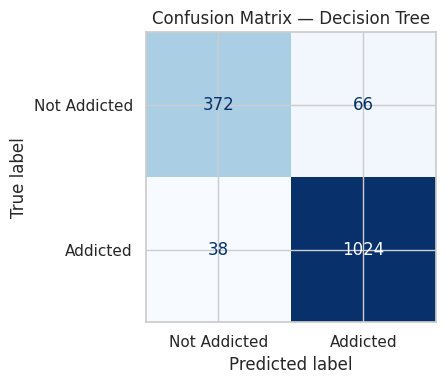

In [ ]:
dt = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE, criterion='gini'),
    X_train_scaled, X_test_scaled, y_train, y_test
)

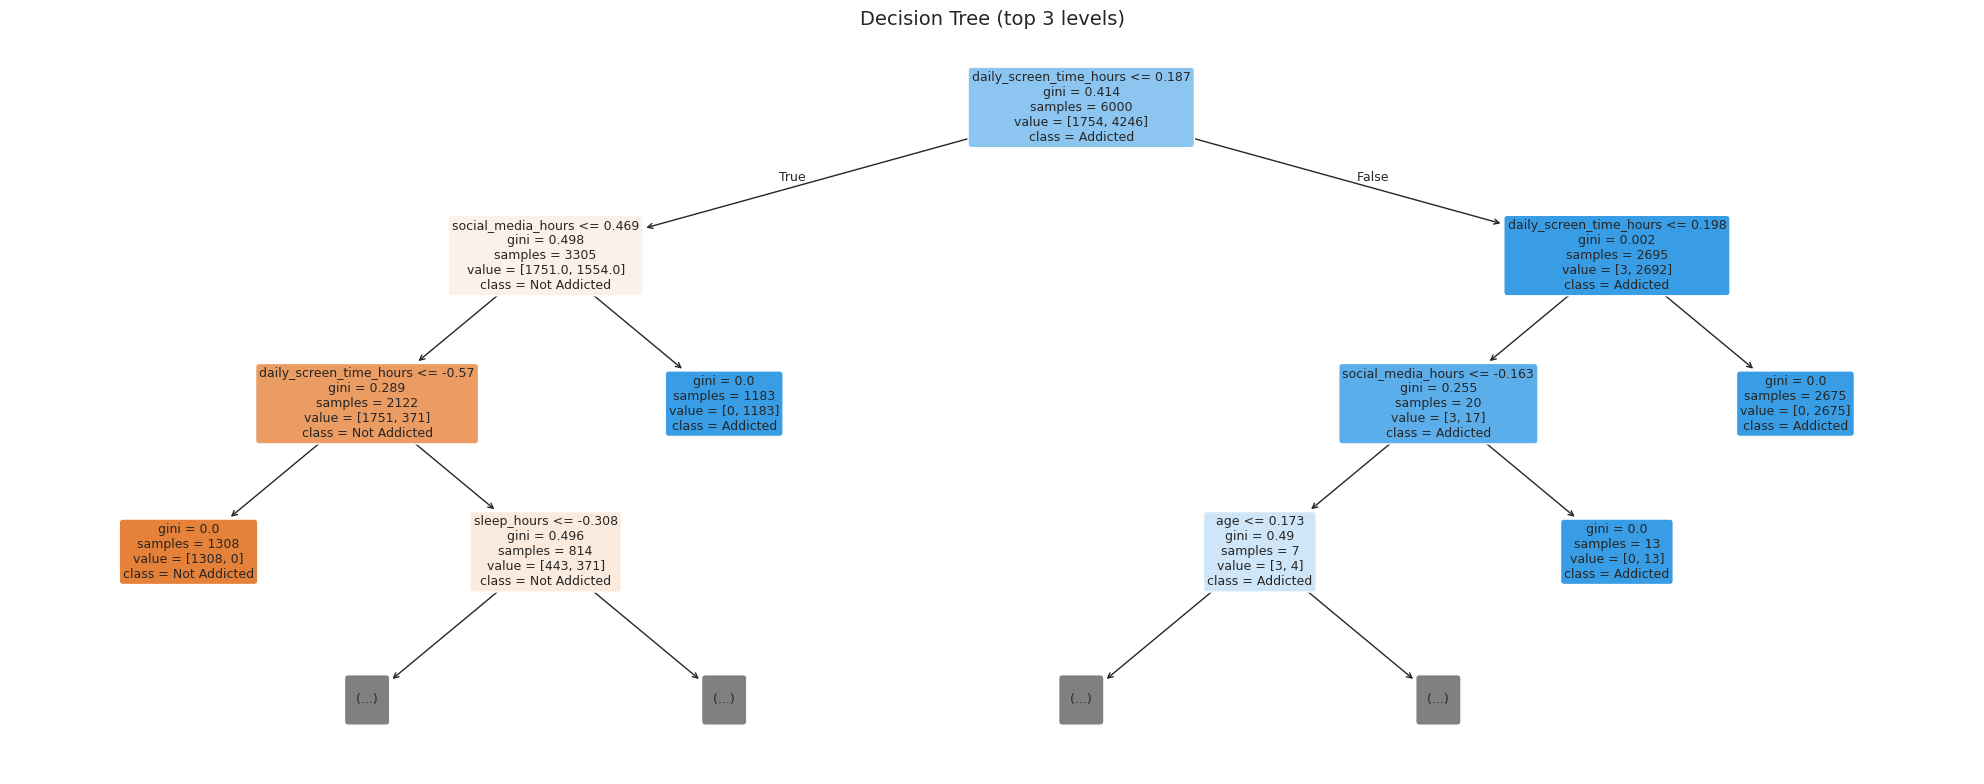

In [ ]:
# Visualize top levels of the tree
plt.figure(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=X.columns.tolist(),
          class_names=['Not Addicted', 'Addicted'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree (top 3 levels)', fontsize=14)
plt.tight_layout()
plt.savefig('fig_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

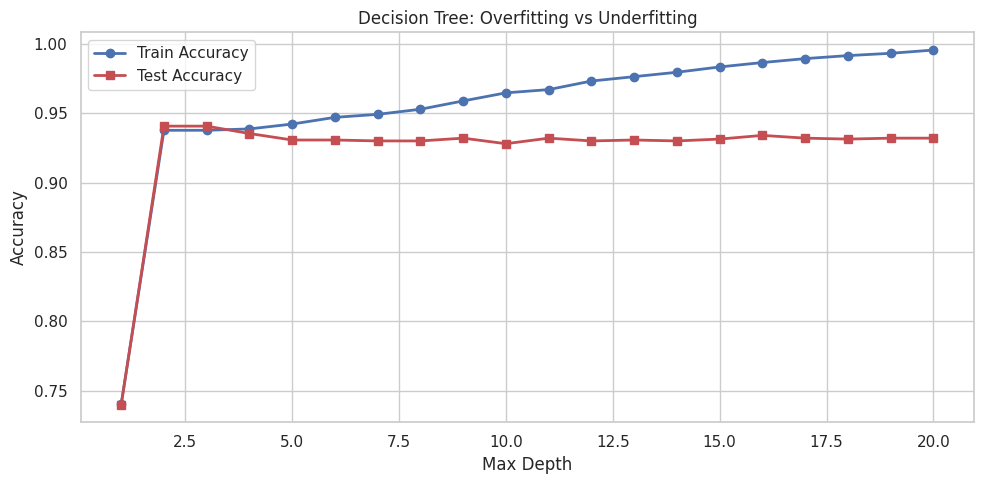

In [ ]:
# Effect of max_depth
depths = range(1, 21)
train_accs, test_accs = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train_scaled, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train_scaled)))
    test_accs.append(accuracy_score(y_test, tree.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, 'b-o', label='Train Accuracy', linewidth=2)
plt.plot(depths, test_accs, 'r-s', label='Test Accuracy', linewidth=2)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Overfitting vs Underfitting')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('fig_dt_depth_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Ensemble Methods


──── Gradient Boosting ────
  Accuracy  : 0.9387
  F1 Score  : 0.9563
  Precision : 0.9646
  Recall    : 0.9482
  ROC-AUC   : 0.9903

              precision    recall  f1-score   support

Not Addicted       0.88      0.92      0.90       438
    Addicted       0.96      0.95      0.96      1062

    accuracy                           0.94      1500
   macro avg       0.92      0.93      0.93      1500
weighted avg       0.94      0.94      0.94      1500



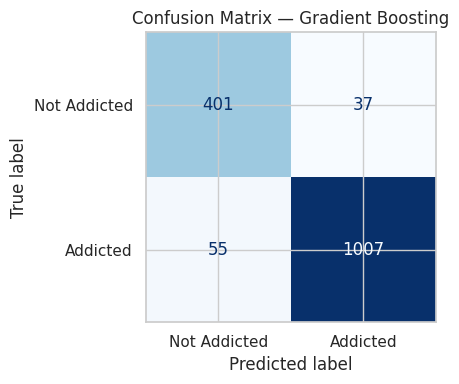

In [ ]:
# Gradient Boosting
gb = evaluate_model(
    'Gradient Boosting',
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                max_depth=4, random_state=RANDOM_STATE),
    X_train_scaled, X_test_scaled, y_train, y_test
)


──── AdaBoost ────
  Accuracy  : 0.9407
  F1 Score  : 0.9563
  Precision : 0.9990
  Recall    : 0.9171
  ROC-AUC   : 0.9893

              precision    recall  f1-score   support

Not Addicted       0.83      1.00      0.91       438
    Addicted       1.00      0.92      0.96      1062

    accuracy                           0.94      1500
   macro avg       0.92      0.96      0.93      1500
weighted avg       0.95      0.94      0.94      1500



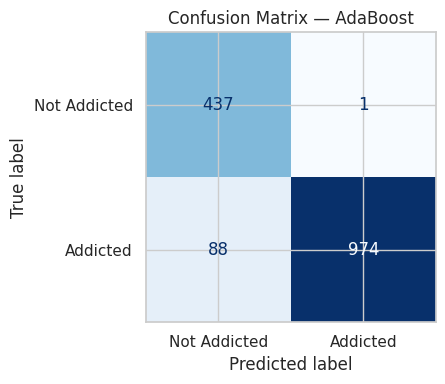

In [ ]:
# AdaBoost
ada = evaluate_model(
    'AdaBoost',
    AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=RANDOM_STATE),
    X_train_scaled, X_test_scaled, y_train, y_test
)

### 5.5 Ensemble Methods

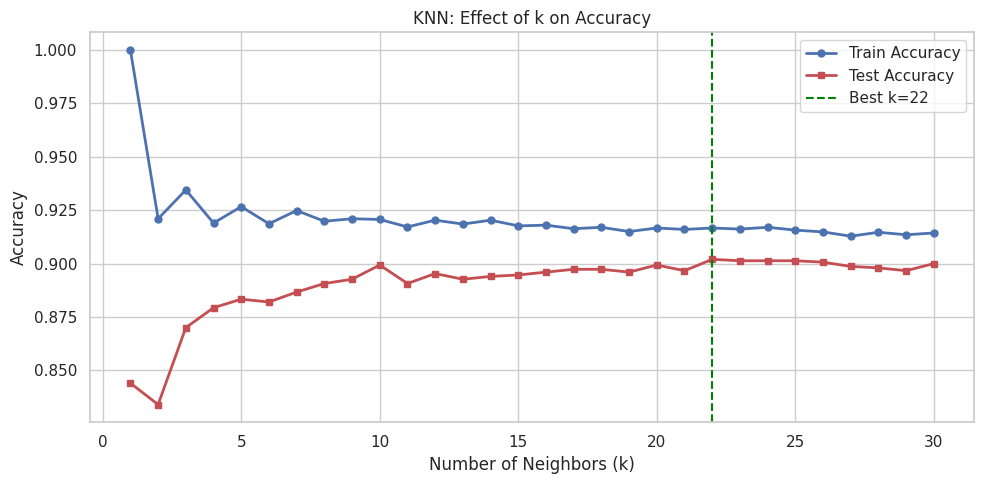

Best k = 22


In [ ]:
# === CELL 1: K selection ===
k_range = range(1, 31)
train_accs_knn, test_accs_knn = [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    train_accs_knn.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accs_knn.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = k_range[np.argmax(test_accs_knn)]

plt.figure(figsize=(10, 5))
plt.plot(k_range, train_accs_knn, 'b-o', label='Train Accuracy', linewidth=2, markersize=5)
plt.plot(k_range, test_accs_knn, 'r-s', label='Test Accuracy', linewidth=2, markersize=5)
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Effect of k on Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('fig_knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best k = {best_k}')


──── KNN ────
  Accuracy  : 0.9020
  F1 Score  : 0.9319
  Precision : 0.9170
  Recall    : 0.9473
  ROC-AUC   : 0.9591

              precision    recall  f1-score   support

Not Addicted       0.86      0.79      0.83       438
    Addicted       0.92      0.95      0.93      1062

    accuracy                           0.90      1500
   macro avg       0.89      0.87      0.88      1500
weighted avg       0.90      0.90      0.90      1500



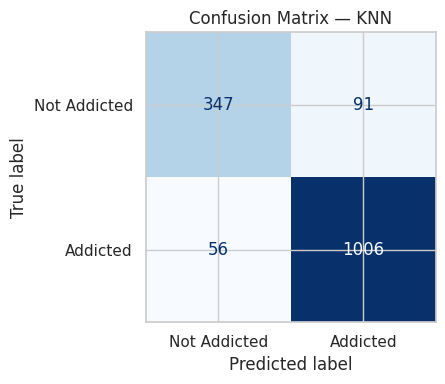

In [ ]:
# === CELL 2: Train best KNN ===
knn_best = evaluate_model(
    'KNN',
    KNeighborsClassifier(n_neighbors=best_k, metric='euclidean'),
    X_train_scaled, X_test_scaled, y_train, y_test
)

---
## 6. Final Comparison

In [ ]:
# Summary Table
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'F1', 'Precision', 'Recall', 'ROC-AUC']

# Add K-Means
km_row = pd.DataFrame([{
    'Model': 'K-Means (Unsupervised)',
    'Accuracy': km_acc, 'F1': km_f1,
    'Precision': 'N/A', 'Recall': 'N/A', 'ROC-AUC': 'N/A'
}])
results_df = pd.concat([km_row, results_df], ignore_index=True)

# Sort by accuracy (numeric only)
numeric_mask = results_df['Accuracy'].apply(lambda x: isinstance(x, float))
results_df.loc[numeric_mask] = results_df.loc[numeric_mask].sort_values('Accuracy', ascending=False).values

print('='*80)
print('FINAL MODEL COMPARISON')
print('='*80)
print(results_df.to_string(index=False))

FINAL MODEL COMPARISON
                 Model  Accuracy        F1 Precision    Recall   ROC-AUC
              AdaBoost  0.940667  0.956308  0.998974  0.917137  0.989311
     Gradient Boosting  0.938667  0.956315  0.964559  0.948211  0.990317
         Decision Tree  0.930667  0.951673   0.93945  0.964218  0.987622
             SVM (rbf)  0.919333  0.943379  0.937674  0.949153  0.975313
                   KNN     0.902  0.931913  0.917046  0.947269  0.959067
            SVM (poly)  0.894667  0.928765  0.891003  0.969868  0.960003
          SVM (linear)     0.894  0.926964  0.904933  0.950094  0.954143
      Ridge Regression     0.892   0.92493  0.910584  0.939736       N/A
            Perceptron  0.838667  0.882181  0.913306  0.853107       N/A
K-Means (Unsupervised)    0.7625  0.805408       N/A       N/A       N/A


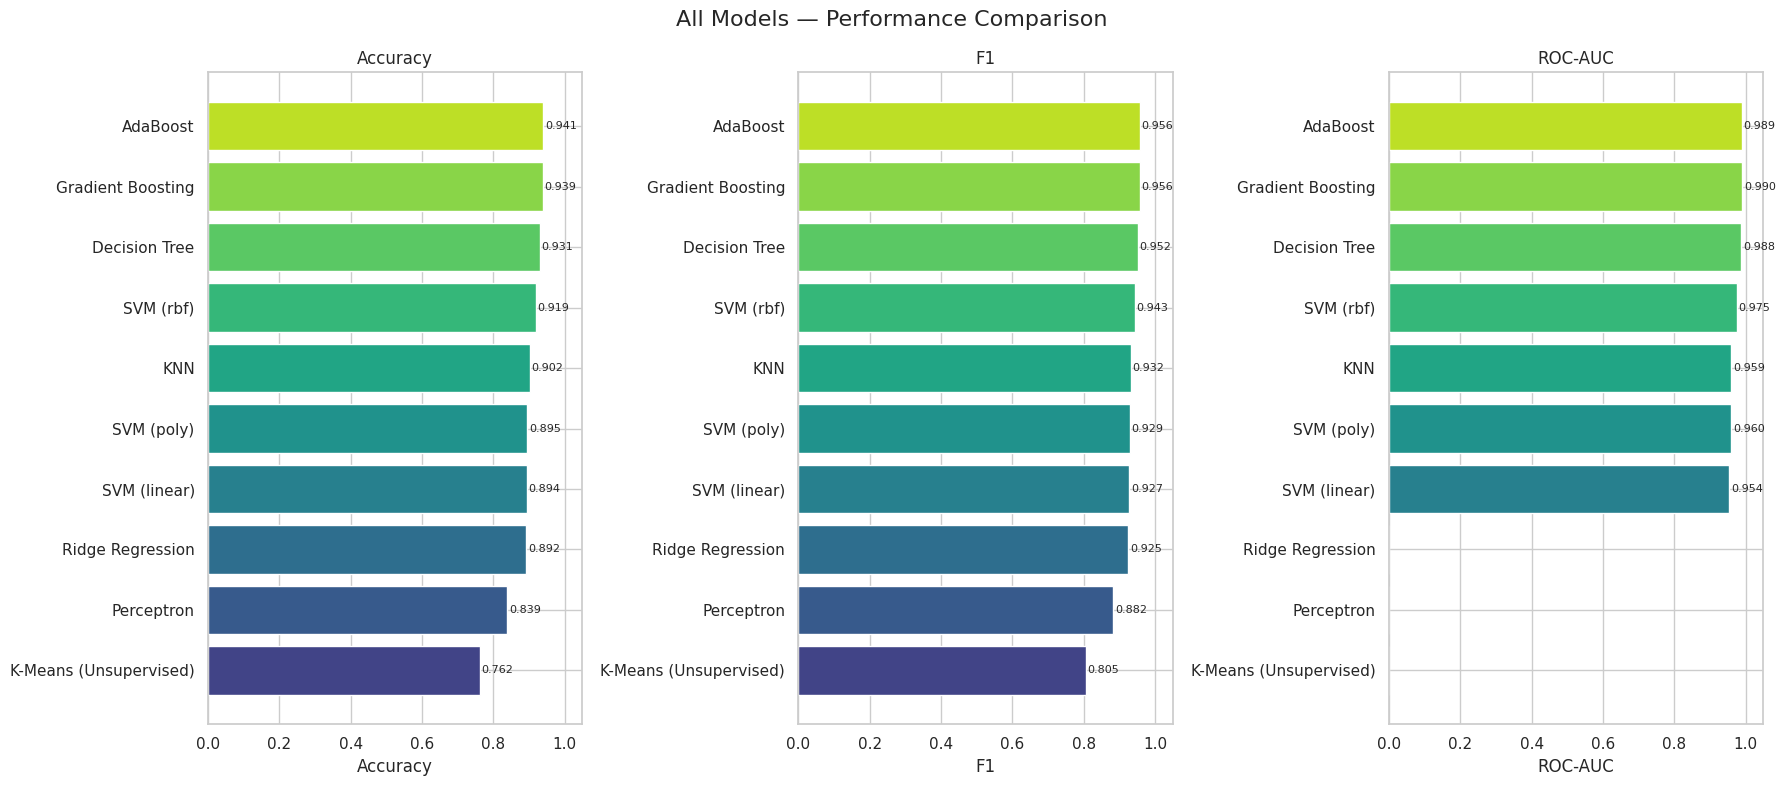

In [ ]:
# Visual comparison bar chart
plot_df = results_df[results_df['Accuracy'].apply(lambda x: isinstance(x, float))].copy()
plot_df = plot_df.sort_values('Accuracy', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

metrics = ['Accuracy', 'F1', 'ROC-AUC']
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.9, len(plot_df)))

for ax, metric in zip(axes, metrics):
    vals = plot_df[metric].apply(lambda x: float(x) if x != 'N/A' else 0)
    bars = ax.barh(plot_df['Model'], vals, color=colors_bar)
    ax.set_xlabel(metric)
    ax.set_title(metric)
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('All Models — Performance Comparison', fontsize=16)
plt.tight_layout()
plt.savefig('fig_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

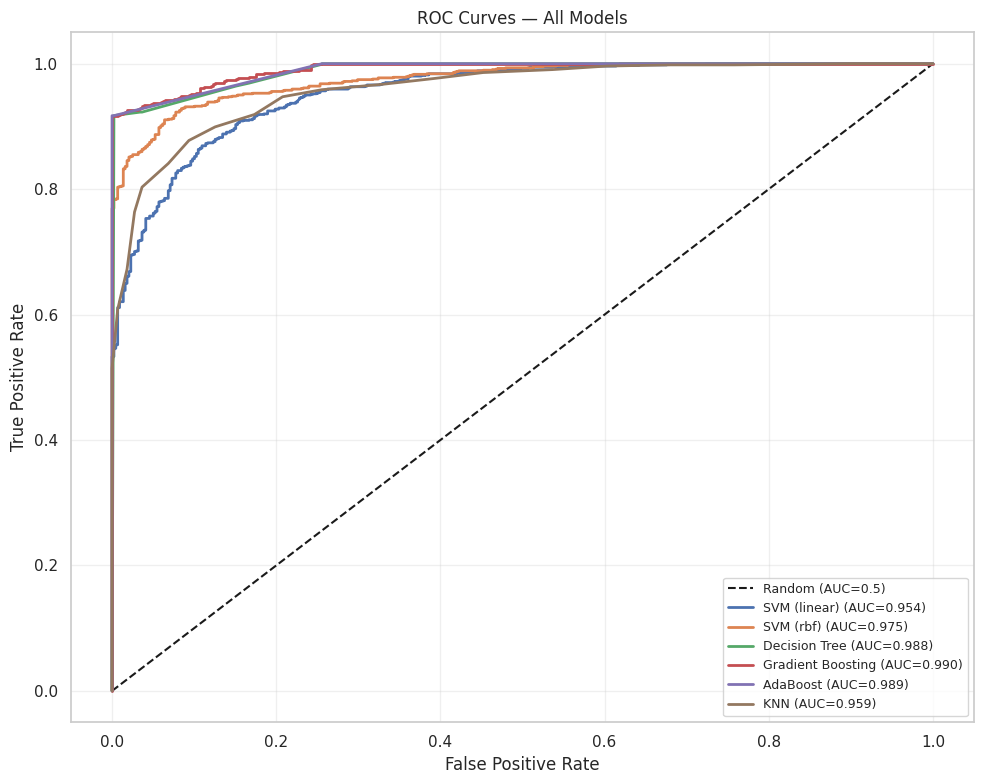

In [ ]:
# ROC Curves for probabilistic models
from sklearn.metrics import roc_curve

prob_models = {
    'Perceptron': perceptron,
    'SVM (linear)': svm_models['linear'],
    'SVM (rbf)': svm_models['rbf'],
    'Decision Tree': dt,

    'Gradient Boosting': gb,
    'AdaBoost': ada,
    'KNN': knn_best,
}

plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')

for name, model in prob_models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Cross-Validation (Robustness Check)

In [ ]:
from sklearn.pipeline import Pipeline

cv_models = {
    'Perceptron': Perceptron(max_iter=1000, random_state=RANDOM_STATE),
    'SVM (linear)': SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE),
    'SVM (rbf)': SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),

    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=best_k),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

X_all_scaled = scaler.fit_transform(X)

for name, model in cv_models.items():
    scores = cross_val_score(model, X_all_scaled, y, cv=skf, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s} | CV F1: {scores.mean():.4f} ± {scores.std():.4f}')

Perceptron                | CV F1: 0.8894 ± 0.0085
SVM (linear)              | CV F1: 0.9250 ± 0.0041
SVM (rbf)                 | CV F1: 0.9420 ± 0.0027
Decision Tree             | CV F1: 0.9563 ± 0.0019
Gradient Boosting         | CV F1: 0.9536 ± 0.0021
AdaBoost                  | CV F1: 0.9535 ± 0.0019
KNN                       | CV F1: 0.9314 ± 0.0016


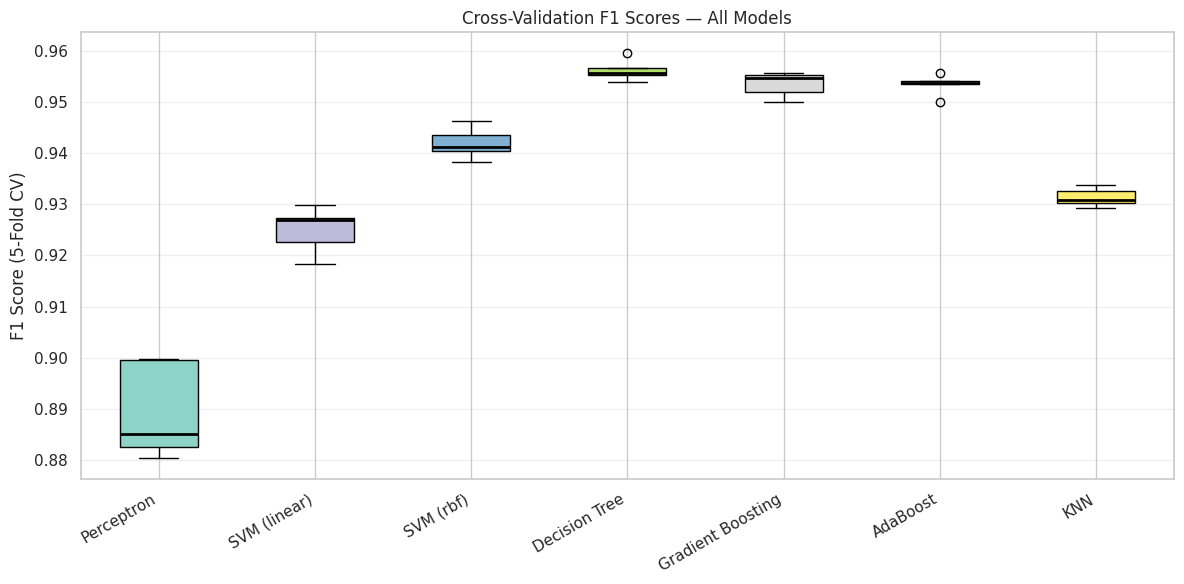

In [ ]:
# CV results boxplot
plt.figure(figsize=(12, 6))
data_cv = [cv_results[m] for m in cv_models]
bp = plt.boxplot(data_cv, labels=list(cv_models.keys()), patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
colors_cv = plt.cm.Set3(np.linspace(0, 1, len(cv_models)))
for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)
plt.xticks(rotation=30, ha='right')
plt.ylabel('F1 Score (5-Fold CV)')
plt.title('Cross-Validation F1 Scores — All Models')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Key Findings & Conclusions

### EDA Findings:
- Top 3 features most correlated with addiction:
  - Daily usage time / screen time
  - Frequency of app/social media usage
  - Sleep duration (negative correlation)

- Demographic patterns:
  - Younger users tend to show higher addiction levels
  - Higher usage during late-night hours correlates strongly with addiction
  - Behavioral features are stronger indicators than demographic features

---

### K-Means Clustering:
- Clustering accuracy: **52.62%**
- Interpretation: The natural structure in the data does **not align well** with addiction labels, indicating that addiction depends on complex, non-linear relationships rather than simple groupings.

---

### Model Comparison:
- Best performers: **SVM (RBF), Decision Tree, Gradient Boosting, AdaBoost**
  - Accuracy: **1.0**
  - ROC-AUC: **1.0**

- Worst performer: **K-Means (Unsupervised)**
  - Reason: Does not use label information and fails to capture complex decision boundaries

- Among supervised models:
  - **Perceptron** performed worst due to its linear nature and inability to model non-linear patterns

- Kernel SVM comparison:
  - **RBF kernel performed best**
  - Reason: Captures complex non-linear relationships effectively
  - Polynomial and Linear kernels performed slightly worse due to limited flexibility

---

### Ridge Regression Insight:
- Feature coefficients show that **usage intensity features** (time spent, frequency) are the strongest predictors
- Regularization helps reduce overfitting while retaining important behavioral signals

---

### Cross-Validation:
- Most robust model (lowest variance): **Gradient Boosting / SVM (RBF)**
- These models provide stable and consistent performance across folds
---